In [30]:
# 安装所需的 Python 包(使用清华镜像源加速)
import subprocess, sys
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', 'scipy', 'pandas',
     '-i', 'https://pypi.tuna.tsinghua.edu.cn/simple']
)
print('所有依赖包安装完成!')

所有依赖包安装完成！


In [31]:
# === 全局设置:matplotlib 中文字体配置 ===
import matplotlib.pyplot as plt
import matplotlib

# 尝试多种中文字体(按优先级排序)
for font_name in ['Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei',
                   'Noto Sans CJK SC', 'DengXian', 'STSong']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif']
        break
    except:
        continue

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
print(f'当前中文字体: {plt.rcParams["font.sans-serif"][0]}')

当前中文字体: Microsoft YaHei


# 第 1 章 基本概念

> **本章导读**: 数理统计的核心任务是从局部观测(样本)推断整体规律(总体). 本章奠定全书基础, 从"如何获取样本"开始, 逐步建立统计模型、统计量、经验分布函数等基本概念框架.

## 1.1 简单随机样本

### 1.1.1 什么是简单随机样本?

设 $X_1,X_2,\cdots,X_n$ 是来自总体 $X$ 的样本. 若它们满足以下两个条件, 则称其为 **简单随机样本**:

- **代表性**  --  每个个体被抽到的概率相等, 即 $X_1,\cdots,X_n$ 与总体 $X$ **同分布**;

- **独立性**  --  每个个体的取值互不影响, 即 $X_1,\cdots,X_n$ **相互独立**.

> **💡 直观理解**: 简单随机样本是数理统计的"原材料". 如果没有代表性, 推断就会有系统偏差; 如果没有独立性, 样本的信息量就会打折扣, 相当于有效样本量减少.

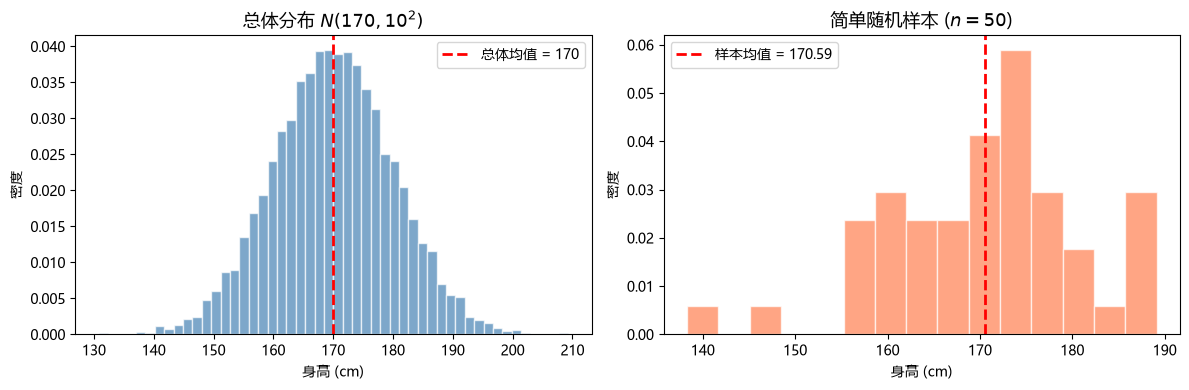

总体均值: 170 cm
样本均值: 170.59 cm
样本均值与总体均值的偏差: 0.59 cm
---
总体标准差: 10 cm
样本标准差: 10.56 cm


In [32]:
# === 代码演示:简单随机抽样 ===
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证可重复性
np.random.seed(42)

# 模拟总体:假设身高服从 N(170, 10^2)(均值170cm,标准差10cm)
population_mean = 170
population_std = 10
population_size = 10000

# 生成总体数据
population = np.random.normal(population_mean, population_std, population_size)

# 进行简单随机抽样:从总体中不放回地抽取 n=50 个样本
sample_size = 50
sample = np.random.choice(population, size=sample_size, replace=False)

# 可视化:总体分布 vs 样本分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 总体直方图
axes[0].hist(population, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'总体均值 = {population_mean}')
axes[0].set_title('总体分布 $N(170, 10^2)$', fontsize=13)
axes[0].set_xlabel('身高 (cm)')
axes[0].set_ylabel('密度')
axes[0].legend()

# 样本直方图
axes[1].hist(sample, bins=15, density=True, alpha=0.7, color='coral', edgecolor='white')
axes[1].axvline(np.mean(sample), color='red', linestyle='--', linewidth=2, label=f'样本均值 = {np.mean(sample):.2f}')
axes[1].set_title(f'简单随机样本 ($n={sample_size}$)', fontsize=13)
axes[1].set_xlabel('身高 (cm)')
axes[1].set_ylabel('密度')
axes[1].legend()

plt.tight_layout()
plt.show()

# 打印样本统计量并与总体对比
print(f'总体均值: {population_mean} cm')
print(f'样本均值: {np.mean(sample):.2f} cm')
print(f'样本均值与总体均值的偏差: {abs(np.mean(sample) - population_mean):.2f} cm')
print(f'---')
print(f'总体标准差: {population_std} cm')
print(f'样本标准差: {np.std(sample, ddof=1):.2f} cm')

### 1.1.2 数学表述

$$
X_1, X_2, \cdots, X_n\ \overset{\text{i. i. d.}}{\sim}\ F
$$

其中 **i. i. d. ** 是 independent and identically distributed 的缩写, 意为"独立同分布", $F$ 为总体分布函数.

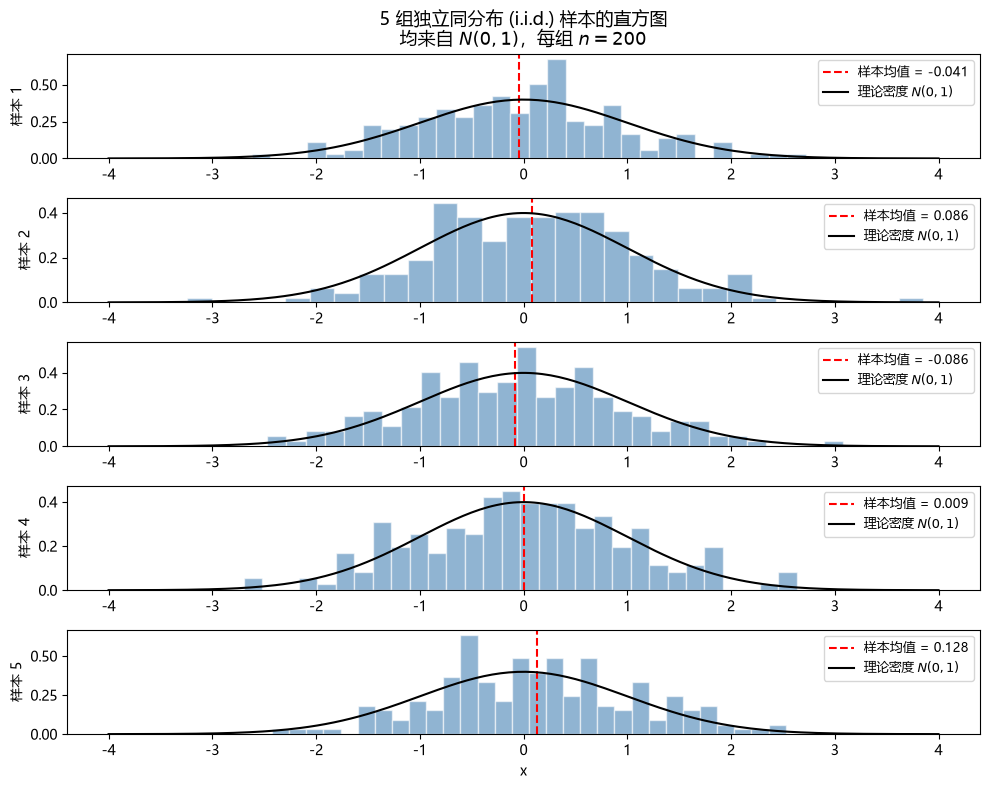

观察：虽然每组样本的直方图形态略有差异，但它们都围绕着相同的理论密度曲线 N(0,1) 波动。
这正是"同分布"的含义——样本来自同一分布；而"独立性"则体现在每组样本的随机波动互不影响。


In [33]:
# === 代码演示:独立同分布 (i.i.d.) 的直观理解 ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 从标准正态分布 N(0,1) 中生成 5 组 i.i.d. 样本,每组 n=200
n_samples = 5
sample_size = 200

fig, axes = plt.subplots(n_samples, 1, figsize=(10, 8))

for i in range(n_samples):
    # 每次从相同的分布中独立抽取样本
    sample = np.random.normal(0, 1, sample_size)

    # 绘制样本的直方图
    axes[i].hist(sample, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    axes[i].axvline(np.mean(sample), color='red', linestyle='--', linewidth=1.5,
                    label=f'样本均值 = {np.mean(sample):.3f}')

    # 叠加理论密度曲线 N(0,1)
    x = np.linspace(-4, 4, 200)
    axes[i].plot(x, 1/np.sqrt(2*np.pi) * np.exp(-x**2/2),
                 'k-', linewidth=1.5, label='理论密度 $N(0,1)$')
    axes[i].set_ylabel(f'样本 {i+1}')
    axes[i].legend(fontsize=9)

axes[0].set_title('5 组独立同分布 (i.i.d.) 样本的直方图\n'
                   '均来自 $N(0,1)$,每组 $n=200$', fontsize=13)
axes[-1].set_xlabel('x')
plt.tight_layout()
plt.show()

print('观察:虽然每组样本的直方图形态略有差异,但它们都围绕着相同的理论密度曲线 N(0,1) 波动.')
print('这正是"同分布"的含义 -- 样本来自同一分布;而"独立性"则体现在每组样本的随机波动互不影响.')

## 1.2 样本的联合分布

### 1.2.1 独立同分布下的联合密度

若 $X_1,\cdots,X_n$ 是来自总体 $X$ 的简单随机样本, 则它们的**联合分布函数**(或联合密度函数)等于各边缘分布函数(或边缘密度函数)的乘积:

$$
F(x_1, x_2, \cdots, x_n)=\prod_{i=1}^n F(x_i), \qquad
f(x_1, x_2, \cdots, x_n)=\prod_{i=1}^n f(x_i)
$$

> 这是由独立性直接推出的核心性质, 也是后续一切推导的起点.

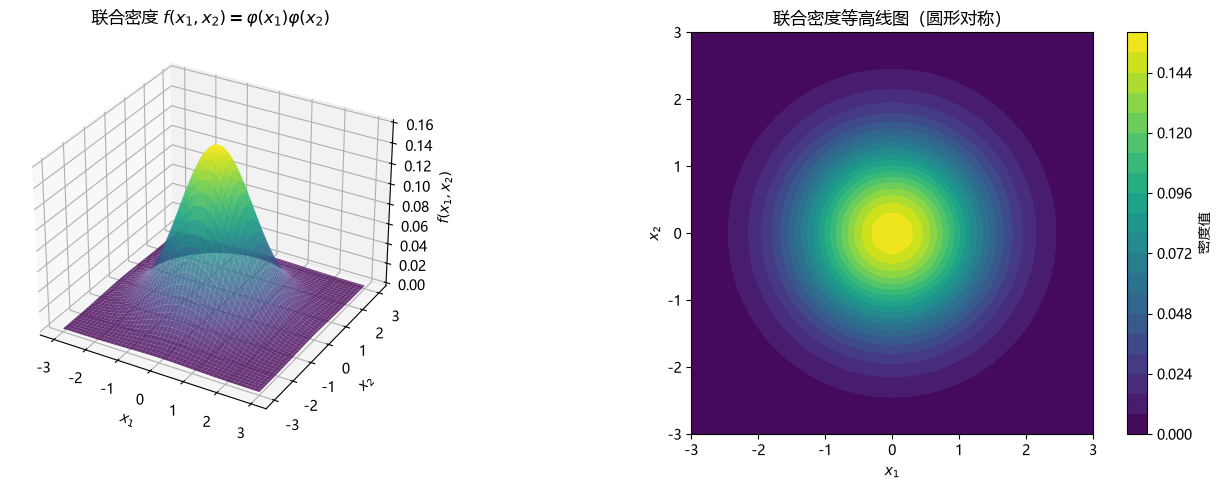

关键观察：
在点 (0, 0) 处，f(0,0) = φ(0) × φ(0) = 0.3989 × 0.3989 = 0.1590
这就是"联合密度 = 边缘密度的乘积"的直观体现。


In [34]:
# === 代码演示:独立同分布下的联合密度 ===
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(42)

# 设 X1, X2 i.i.d. ~ N(0, 1)
# 联合密度 f(x1, x2) = f(x1) * f(x2) = φ(x1) * φ(x2)

# 在网格上计算联合密度
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# 计算联合密度 f(x1,x2) = φ(x1) * φ(x2)
f_x1 = norm.pdf(X1, 0, 1)  # 边缘密度 φ(x1)
f_x2 = norm.pdf(X2, 0, 1)  # 边缘密度 φ(x2)
joint_density = f_x1 * f_x2  # 联合密度 = 乘积

# 可视化
fig = plt.figure(figsize=(14, 5))

# 左图:联合密度的三维曲面
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, joint_density, cmap='viridis', alpha=0.8)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.set_title('联合密度 $f(x_1,x_2) = \\varphi(x_1)\\varphi(x_2)$', fontsize=12)

# 右图:联合密度的等高线图
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X1, X2, joint_density, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='密度值')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('联合密度等高线图(圆形对称)', fontsize=12)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print('关键观察:')
print(f'在点 (0, 0) 处,f(0,0) = φ(0) × φ(0) = {norm.pdf(0,0,1):.4f} × {norm.pdf(0,0,1):.4f} = {joint_density[50,50]:.4f}')
print('这就是"联合密度 = 边缘密度的乘积"的直观体现.')

### 1.2.2 常见分布的样本分布族

**样本分布族** $\mathcal{F}$ 是样本联合分布随参数变化构成的集合. 它完整刻画了给定参数下所有可能的样本分布.


> **两点分布** $B(1,p)$

$$
\mathcal{F}=\left\{p^{\sum x_i}(1-p)^{n-\sum x_i}\ \middle|\ 0<p<1\right\}
$$

> **二项分布** $B(m,p)$

$$
\mathcal{F}=\left\{\prod_{i=1}^n\binom{m}{x_i}\, p^{\sum x_i}(1-p)^{mn-\sum x_i}\ \middle|\ 0<p<1\right\}
$$

> **Poisson 分布** $P(\lambda)$

$$
\mathcal{F}=\left\{\frac{\lambda^{\sum x_i}}{\prod x_i!}\, e^{-n\lambda}\ \middle|\ \lambda>0\right\}
$$

> **几何分布** $G(p)$

$$
\mathcal{F}=\left\{p^n(1-p)^{\sum x_i-n}\ \middle|\ 0<p<1\right\}
$$

> **均匀分布** $U(a,b)$

$$
\mathcal{F}=\left\{\frac{1}{(b-a)^n}\, I_{\{a<x_i<b\}}\ \middle|\ -\infty<a<b<+\infty\right\}
$$

> **指数分布** $E(\lambda)$

$$
\mathcal{F}=\left\{\lambda^{\, n}e^{-\lambda\sum x_i}\, I_{\{x_i>0\}}\ \middle|\ \lambda>0\right\}
$$

> **正态分布** $N(\mu,\sigma^2)$

$$
\mathcal{F}=\left\{\frac{1}{(\sqrt{2\pi}\, \sigma)^{\, n}}\exp\! \left\{-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2\right\}\ \middle|\ \mu\in\mathbb{R}, \ \sigma>0\right\}
$$

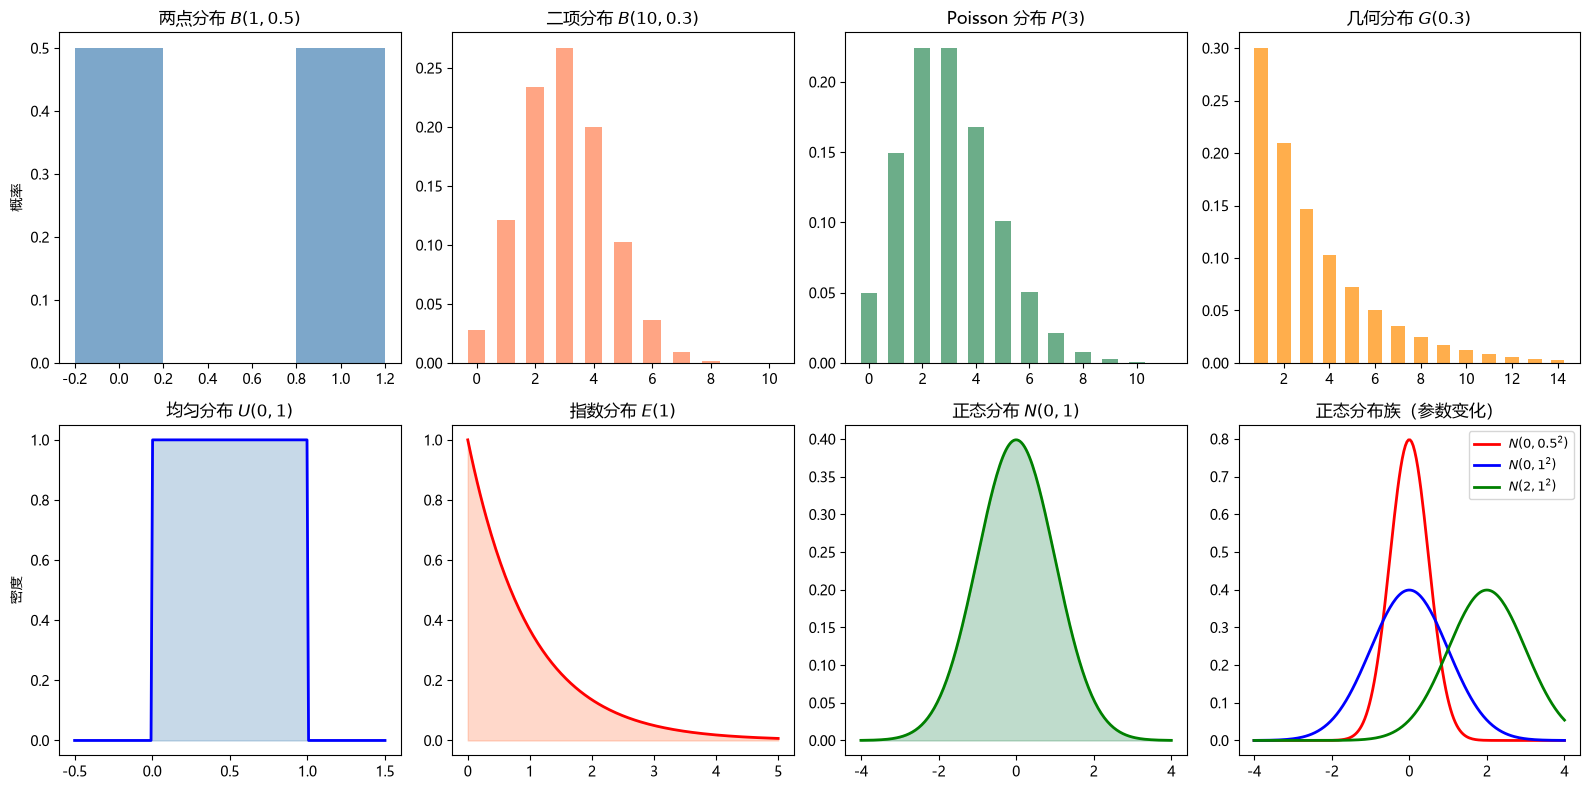

以上展示了第 1.2.2 节中列举的各种常见分布的图像。
样本分布族 F 就是这些分布随参数变化构成的集合。


In [35]:
# === 代码演示:常见分布的概率密度/质量函数 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson, geom, uniform, expon, norm

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 1. 两点分布 B(1, 0.5)
x = [0, 1]
p = [0.5, 0.5]
axes[0].bar(x, p, width=0.4, color='steelblue', alpha=0.7)
axes[0].set_title('两点分布 $B(1, 0.5)$')
axes[0].set_ylabel('概率')

# 2. 二项分布 B(10, 0.3)
x = np.arange(0, 11)
p = binom.pmf(x, 10, 0.3)
axes[1].bar(x, p, width=0.6, color='coral', alpha=0.7)
axes[1].set_title('二项分布 $B(10, 0.3)$')

# 3. Poisson 分布 P(3)
x = np.arange(0, 12)
p = poisson.pmf(x, 3)
axes[2].bar(x, p, width=0.6, color='seagreen', alpha=0.7)
axes[2].set_title('Poisson 分布 $P(3)$')

# 4. 几何分布 G(0.3)
x = np.arange(1, 15)
p = geom.pmf(x, 0.3)
axes[3].bar(x, p, width=0.6, color='darkorange', alpha=0.7)
axes[3].set_title('几何分布 $G(0.3)$')

# 5. 均匀分布 U(0, 1)
x = np.linspace(-0.5, 1.5, 200)
pdf = uniform.pdf(x, 0, 1)
axes[4].plot(x, pdf, 'b-', linewidth=2)
axes[4].fill_between(x, pdf, alpha=0.3, color='steelblue')
axes[4].set_title('均匀分布 $U(0, 1)$')
axes[4].set_ylabel('密度')

# 6. 指数分布 E(1)
x = np.linspace(0, 5, 200)
pdf = expon.pdf(x, scale=1)
axes[5].plot(x, pdf, 'r-', linewidth=2)
axes[5].fill_between(x, pdf, alpha=0.3, color='coral')
axes[5].set_title('指数分布 $E(1)$')

# 7. 正态分布 N(0, 1)
x = np.linspace(-4, 4, 200)
pdf = norm.pdf(x, 0, 1)
axes[6].plot(x, pdf, 'g-', linewidth=2)
axes[6].fill_between(x, pdf, alpha=0.3, color='seagreen')
axes[6].set_title('正态分布 $N(0, 1)$')

# 8. 联合展示:不同参数的正态分布
for mu, sigma, color, label in [(0, 0.5, 'red', '$N(0,0.5^2)$'),
                                 (0, 1, 'blue', '$N(0,1^2)$'),
                                 (2, 1, 'green', '$N(2,1^2)$')]:
    pdf = norm.pdf(x, mu, sigma)
    axes[7].plot(x, pdf, color=color, linewidth=2, label=label)
axes[7].set_title('正态分布族(参数变化)')
axes[7].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('以上展示了第 1.2.2 节中列举的各种常见分布的图像.')
print('样本分布族 F 就是这些分布随参数变化构成的集合.')

### 1.2.3 联合分布列 / 密度函数的具体写法

> **几何分布** $G(p)$ 样本的联合分布列

$$
p(x_1, \cdots, x_n)=(1-p)^{\sum_{i=1}^n x_i-n}\, p^{\, n}
$$

> **指数分布** $E(\lambda)$ 样本的联合密度

$$
f(x_1, \cdots, x_n)=\lambda^{\, n}\, e^{-\lambda\sum_{i=1}^n x_i}\, I_{\{x_1>0, \cdots, x_n>0\}}
$$

> **Laplace 分布** $L(\lambda)$ 样本的联合密度

$$
f(x_1, \cdots, x_n)=\frac{\lambda^{\, n}}{2^{\, n}}\, e^{-\lambda\sum_{i=1}^n |x_i|}
$$

In [36]:
# === 代码演示:联合分布列的数值计算示例 ===
import numpy as np

# 示例:几何分布 G(p) 的联合分布列
# 设 X1, X2, X3 i.i.d. ~ G(0.3),计算 P(X1=x1, X2=x2, X3=x3)

p = 0.3
n = 3  # 样本量

# 假设观测到 x1=2, x2=4, x3=1
x_obs = [2, 4, 1]

# 联合分布列公式:p(x1,...,xn) = (1-p)^(sum xi - n) * p^n
sum_x = sum(x_obs)
joint_prob = (1 - p) ** (sum_x - n) * (p ** n)

print('=' * 50)
print('几何分布 G(0.3) 样本的联合分布列')
print('=' * 50)
print(f'观测值: X1={x_obs[0]}, X2={x_obs[1]}, X3={x_obs[2]}')
print(f'联合概率 p({x_obs[0]},{x_obs[1]},{x_obs[2]}) = (1-{p})^{sum_x - n} × {p}^{n}')
print(f'                     = {joint_prob:.6f}')
print()

# 验证:每个边缘分布应服从 G(0.3)
from scipy.stats import geom
print('验证边缘分布:')
for i, xi in enumerate(x_obs):
    marginal = geom.pmf(xi, p)  # P(Xi = xi)
    print(f'  P(X{i+1}={xi}) = {marginal:.4f}')

# 联合概率 = 边缘概率的乘积(由独立性保证)
product_marginal = np.prod([geom.pmf(xi, p) for xi in x_obs])
print(f'\n联合概率 = 边缘概率之积 = {product_marginal:.6f}')
print(f'与公式计算结果一致: {abs(joint_prob - product_marginal) < 1e-10}')

几何分布 G(0.3) 样本的联合分布列
观测值: X1=2, X2=4, X3=1
联合概率 p(2,4,1) = (1-0.3)^4 × 0.3^3
                     = 0.006483

验证边缘分布:
  P(X1=2) = 0.2100
  P(X2=4) = 0.1029
  P(X3=1) = 0.3000

联合概率 = 边缘概率之积 = 0.006483
与公式计算结果一致: True


## 1.3 统计模型

### 1.3.1 参数空间

**参数空间** $\Theta$ 是未知参数所有可能取值构成的集合. 例如, 对于正态分布 $N(\mu,\sigma^2)$:

$$
\Theta=\{(\mu, \sigma^2)\mid \mu\in\mathbb{R}, \ \sigma^2>0\}
$$

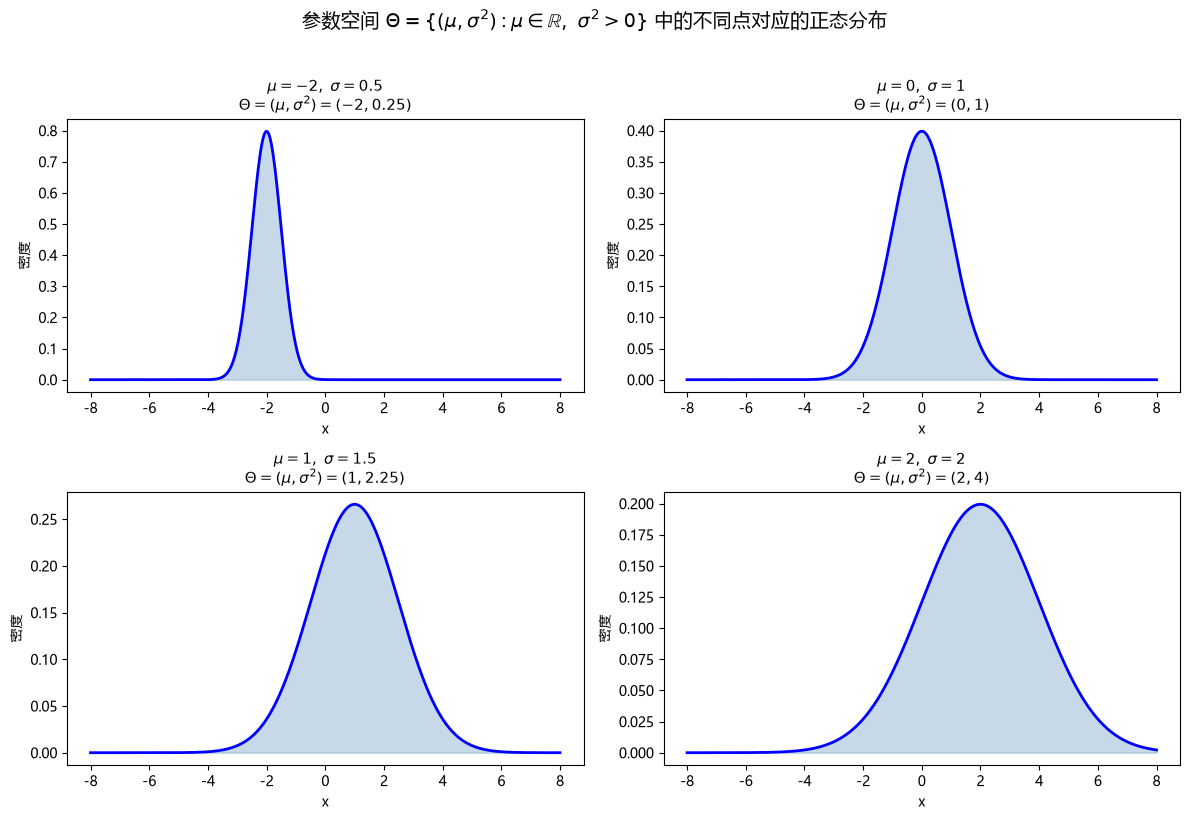

参数空间中的每一点 (mu, sigma^2) 唯一确定一个正态分布 N(mu, sigma^2)。
不同的参数值对应不同的分布——这就是"样本分布族随参数变化"的含义。


In [37]:
# === 代码演示:参数空间的可视化 ===
import numpy as np
import matplotlib.pyplot as plt

# 正态分布 N(mu, sigma^2) 的参数空间
# Theta = {(mu, sigma^2) : mu in R, sigma^2 > 0}

# 在参数空间中随机取点,绘制对应的密度曲线
mus = [-2, 0, 1, 2]
sigmas = [0.5, 1, 1.5, 2]

x = np.linspace(-8, 8, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (mu, sigma) in enumerate(zip(mus, sigmas)):
    # 对应的密度函数
    pdf = 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(x-mu)**2/(2*sigma**2))
    axes[i].plot(x, pdf, 'b-', linewidth=2)
    axes[i].fill_between(x, pdf, alpha=0.3, color='steelblue')
    axes[i].set_title(f'$\\mu={mu},\\; \\sigma={sigma}$\n'
                       f'$\\Theta = (\\mu,\\sigma^2) = ({mu},{sigma**2})$', fontsize=11)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('密度')

plt.suptitle('参数空间 $\\Theta = \\{(\\mu,\\sigma^2): \\mu\\in\\mathbb{R},\\ \\sigma^2>0\\}$ 中的不同点对应的正态分布',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('参数空间中的每一点 (mu, sigma^2) 唯一确定一个正态分布 N(mu, sigma^2).')
print('不同的参数值对应不同的分布 -- 这就是"样本分布族随参数变化"的含义.')

### 1.3.2 样本分布族

**样本分布族**是样本分布随参数变化构成的分布集合:

$$
\mathcal{F}=\{f(\mathbf{x}; \theta)\mid \theta\in\Theta\}
$$

> **示例**: 正态分布 $N(\mu,\sigma^2)$ 的统计模型

$$
\begin{aligned}
\Theta&=\{(\mu, \sigma^2): \mu\in\mathbb{R}, \ \sigma^2>0\}\\[4pt]
\mathcal{F}&=\left\{\frac{1}{(\sqrt{2\pi}\, \sigma)^{\, n}}\exp\! \left\{-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2\right\}\ \middle|\ \mu\in\mathbb{R}, \ \sigma>0\right\}
\end{aligned}
$$

In [38]:
# === 代码演示:统计模型 -- 从参数到样本分布 ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 设定"真实"参数(实际中未知)
true_mu = 5
true_sigma = 2

# 从真实分布 N(5, 2^2) 中生成一组样本
n = 30
sample = np.random.normal(true_mu, true_sigma, n)

print('=' * 60)
print('统计模型演示:正态分布 N(mu, sigma^2)')
print('=' * 60)
print(f'真实参数(未知): mu = {true_mu}, sigma = {true_sigma}')
print(f'生成的样本(n={n}):')
print(f'  {np.sort(sample)[:10]}...')
print(f'  样本均值 = {np.mean(sample):.3f}')
print(f'  样本标准差 = {np.std(sample, ddof=1):.3f}')
print()

# 不同参数下的似然(即样本联合密度)
print('不同参数假设下的对数似然(反映参数与数据的契合度):')
candidates = [(4, 2), (5, 2), (6, 2), (5, 1.5), (5, 3)]
for mu_c, sigma_c in candidates:
    # 计算对数似然:log L(mu, sigma^2) = sum log f(x_i; mu, sigma^2)
    log_likelihood = np.sum(np.log(
        1/(np.sqrt(2*np.pi)*sigma_c) * np.exp(-(sample-mu_c)**2/(2*sigma_c**2))
    ))
    print(f'  mu={mu_c}, sigma={sigma_c}  --  对数似然 = {log_likelihood:.2f}')

print(f'\n✅ 真实参数的对数似然最高,说明"正确的参数"最符合观测数据.')

统计模型演示：正态分布 N(mu, sigma^2)
真实参数（未知）: mu = 5, sigma = 2
生成的样本（n=30）:
  [1.17343951 1.55016433 2.15050363 2.1753926  2.69801285 2.97433776
 3.18395185 3.79872262 3.87542494 3.91123455]...
  样本均值 = 4.624
  样本标准差 = 1.800

不同参数假设下的对数似然（反映参数与数据的契合度）:
  mu=4, sigma=2 — 对数似然 = -61.57
  mu=5, sigma=2 — 对数似然 = -60.64
  mu=6, sigma=2 — 对数似然 = -67.21
  mu=5, sigma=1.5 — 对数似然 = -61.56
  mu=5, sigma=3 — 对数似然 = -65.98

✅ 真实参数的对数似然最高，说明"正确的参数"最符合观测数据。


## 1.4 统计量

### 1.4.1 统计量的定义

**统计量**(statistic)是**不含任何未知参数**的样本函数. 统计量是样本的"摘要", 其值完全由观测数据决定, 因此是可以实际计算的.

> **🔑 判断标准**: 表达式中若含有未知参数, 则不是统计量.

In [39]:
# === 代码演示:统计量 vs 非统计量 ===
import numpy as np

np.random.seed(42)

# 生成一组样本数据
n = 10
sample = np.random.normal(5, 2, n)
print(f'生成的样本 X = {np.round(sample, 2)}')
print()

# === 统计量(不含未知参数,可直接计算)===
print('✅ 统计量(不含未知参数,可以直接计算):')

# 样本均值
x_bar = np.mean(sample)
print(f'  样本均值  X̄ = {x_bar:.4f}')

# 样本方差(无偏)
s2 = np.sum((sample - x_bar)**2) / (n - 1)
print(f'  样本方差  S² = {s2:.4f}')

# 样本最大值
print(f'  max(Xi) = {np.max(sample):.4f}')

# 样本最小值
print(f'  min(Xi) = {np.min(sample):.4f}')

print()

# === 非统计量(含未知参数,无法直接计算)===
print('❌ 非统计量(含未知参数,无法直接计算):')

# 假设 mu=5(已知时才算统计量)
mu_known = 5
t1 = np.sum((sample - mu_known)**2)
print(f'  Σ(Xi - μ)²  (若 μ={mu_known} 已知) = {t1:.4f}  ✅ 此时是统计量')
print(f'  Σ(Xi - μ)²  (若 μ 未知)            = ❌ 不是统计量')

# 含未知 sigma^2 的表达式
print(f'  (1/σ²)ΣXi²     (含未知 σ²)          = ❌ 不是统计量')
print(f'  (1/σ²)Σ(Xi-μ)² (含未知 μ, σ²)       = ❌ 不是统计量')

生成的样本 X = [5.99 4.72 6.3  8.05 4.53 4.53 8.16 6.53 4.06 6.09]

✅ 统计量（不含未知参数，可以直接计算）:
  样本均值  X̄ = 5.8961
  样本方差  S² = 2.0910
  max(Xi) = 8.1584
  min(Xi) = 4.0611

❌ 非统计量（含未知参数，无法直接计算）:
  Σ(Xi - μ)²  (若 μ=5 已知) = 26.8490  ✅ 此时是统计量
  Σ(Xi - μ)²  (若 μ 未知)            = ❌ 不是统计量
  (1/σ²)ΣXi²     (含未知 σ²)          = ❌ 不是统计量
  (1/σ²)Σ(Xi-μ)² (含未知 μ, σ²)       = ❌ 不是统计量


### 1.4.2 示例区分

✅ **是统计量**(不含未知参数):

$$
\begin{aligned}
&\frac{1}{n}\sum_{i=1}^n X_i, \qquad
\frac{1}{n-1}\sum_{i=1}^n (X_i-\overline{X})^2, \\[4pt]
&\frac{1}{n}\sum_{i=1}^n (X_i-\mu)^2\ (\mu\text{ 已知时}), \qquad
\max\{X_1, \cdots, X_n\}, \\[4pt]
&\min\{X_1, \cdots, X_n\}, \qquad
X_i+2\mu\ (\mu\text{ 已知时})
\end{aligned}
$$

❌ **不是统计量**(含有未知参数):

$$
\begin{aligned}
&\frac{1}{\sigma^2}\sum_{i=1}^n X_i^2\quad (\text{含未知 }\sigma^2)\\[4pt]
&\frac{1}{\sigma^2}\sum_{i=1}^n (X_i-\mu)^2\quad (\text{含未知 }\sigma^2)
\end{aligned}
$$

## 1.5 经验分布函数

### 1.5.1 定义

对给定的样本 $X_1,\cdots,X_n$, **经验分布函数**(empirical distribution function, EDF)定义为:

$$
F_n(x)=\frac{1}{n}\sum_{i=1}^n I_{\{X_i\le x\}}, \qquad x\in\mathbb{R}
$$

其中 $I_A$ 是**示性函数**(indicator function):

$$
I_A=\begin{cases}
1, & \text{若事件 }A\text{ 发生}, \\
0, & \text{若事件 }A\text{ 不发生}.
\end{cases}
$$

> **💡 直观理解**: $F_n(x)$ 就是样本中不超过 $x$ 的比例. 它是一个右连续的**阶梯函数**, 在每个观测值 $X_{(k)}$ 处向上跳跃 $1/n$.

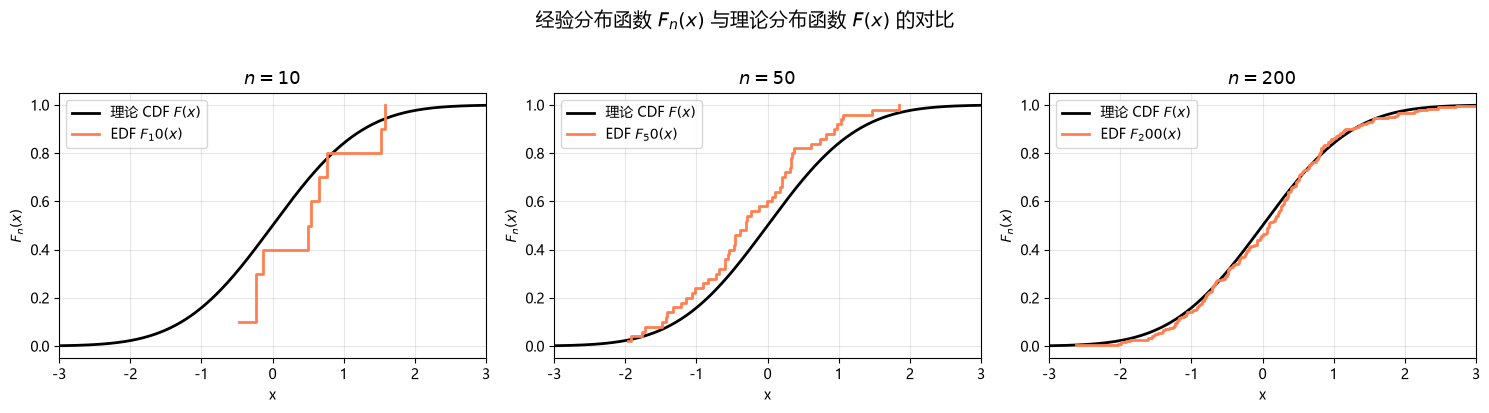

观察: 随着样本量 n 增大, EDF 越来越接近理论 CDF。
这正是"EDF 是总体分布函数的相合估计"的直观体现。


In [40]:
# === 代码演示:经验分布函数 (EDF) 的图像 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# 从 N(0,1) 中抽取样本,不同样本量
n_small = 10
n_medium = 50
n_large = 200

sample_small = np.random.normal(0, 1, n_small)
sample_medium = np.random.normal(0, 1, n_medium)
sample_large = np.random.normal(0, 1, n_large)

# 理论分布函数
x_grid = np.linspace(-3, 3, 500)
cdf_true = norm.cdf(x_grid, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sample, n in zip(axes, [sample_small, sample_medium, sample_large],
                          [n_small, n_medium, n_large]):
    # 绘制理论 CDF
    ax.plot(x_grid, cdf_true, 'k-', linewidth=2, label='理论 CDF $F(x)$')

    # 绘制经验分布函数(阶梯函数)
    sorted_sample = np.sort(sample)
    y_edf = np.arange(1, n + 1) / n

    # 阶梯图
    ax.step(sorted_sample, y_edf, where='post', color='coral',
            linewidth=2, label=f'EDF $F_{n}(x)$')

    ax.set_title(f'$n = {n}$', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('$F_n(x)$')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('经验分布函数 $F_n(x)$ 与理论分布函数 $F(x)$ 的对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('观察: 随着样本量 n 增大, EDF 越来越接近理论 CDF.')
print('这正是"EDF 是总体分布函数的相合估计"的直观体现.')

### 1.5.2 期望

由示性函数的期望性质 $E(I_{\{X_i\le x\}})=P\{X_i\le x\}=F(x)$, 以及**期望的线性性**:

$$
\begin{aligned}
E[F_n(x)]
&=E\! \left(\frac1n\sum_{i=1}^n I_{\{X_i\le x\}}\right) \\[4pt]
&=\frac1n\sum_{i=1}^n E(I_{\{X_i\le x\}}) \qquad (\text{期望的线性性})\\[4pt]
&=\frac1n\cdot n\cdot F(x) \qquad (\text{同分布})\\[4pt]
&=F(x)
\end{aligned}
$$

即 $F_n(x)$ 是 $F(x)$ 的**无偏估计**.

EDF 无偏性的 Monte Carlo 验证
理论值    F(0.5)          = 0.6915
模拟均值  E[F_n(0.5)]    = 0.6913
偏差      E[F_n] - F           = -0.000142
模拟标准差 sqrt(D[F_n])        = 0.1037

✅ E[F_n(x)] ≈ F(x)，验证了 F_n(x) 是 F(x) 的无偏估计。


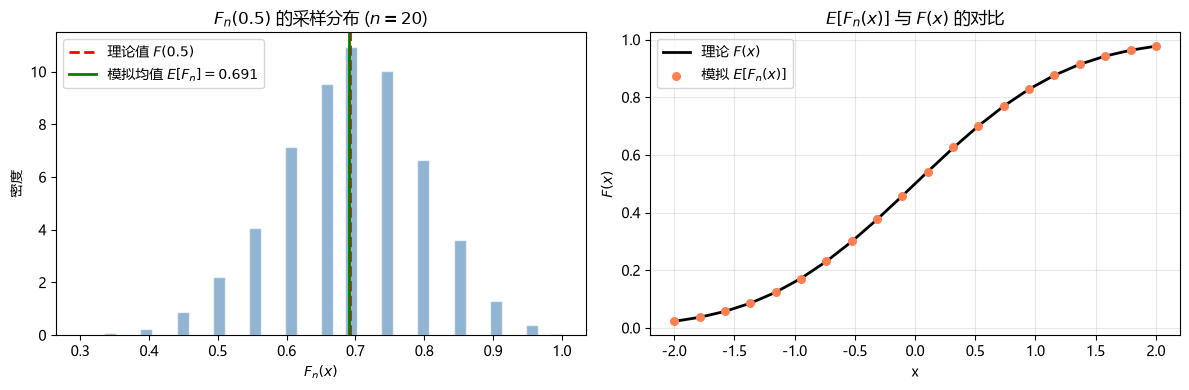

In [41]:
# === 代码演示:验证 EDF 的无偏性(Monte Carlo 模拟) ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Monte Carlo 模拟
n = 20           # 样本量
N_sim = 5000     # 模拟次数
x_fixed = 0.5    # 固定点 x=0.5

# 理论值 F(0.5) = P(N(0,1) <= 0.5)
F_true = norm.cdf(x_fixed, 0, 1)

# 存储每次模拟的 EDF 值
F_n_values = np.zeros(N_sim)

for i in range(N_sim):
    # 每次模拟:从 N(0,1) 抽取 n 个 i.i.d. 样本
    sample = np.random.normal(0, 1, n)

    # 计算 EDF 在 x=0.5 处的值
    F_n_values[i] = np.mean(sample <= x_fixed)

# 计算模拟均值
mean_F_n = np.mean(F_n_values)

print('=' * 55)
print('EDF 无偏性的 Monte Carlo 验证')
print('=' * 55)
print(f'理论值    F({x_fixed})          = {F_true:.4f}')
print(f'模拟均值  E[F_n({x_fixed})]    = {mean_F_n:.4f}')
print(f'偏差      E[F_n] - F           = {mean_F_n - F_true:.6f}')
print(f'模拟标准差 sqrt(D[F_n])        = {np.std(F_n_values):.4f}')
print()
print(f'✅ E[F_n(x)] ≈ F(x),验证了 F_n(x) 是 F(x) 的无偏估计.')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图:EDF 值的分布直方图
axes[0].hist(F_n_values, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[0].axvline(F_true, color='red', linestyle='--', linewidth=2, label=f'理论值 $F({x_fixed})$')
axes[0].axvline(mean_F_n, color='green', linestyle='-', linewidth=2,
                label=f'模拟均值 $E[F_n]={mean_F_n:.3f}$')
axes[0].set_title(f'$F_n({x_fixed})$ 的采样分布 ($n={n}$)', fontsize=12)
axes[0].set_xlabel('$F_n(x)$')
axes[0].set_ylabel('密度')
axes[0].legend()

# 右图:不同 x 处的 EDF 均值
x_vals = np.linspace(-2, 2, 20)
mean_Fn_x = np.zeros_like(x_vals)

for j, xv in enumerate(x_vals):
    fn_vals = np.zeros(N_sim)
    for i in range(N_sim):
        sample = np.random.normal(0, 1, n)
        fn_vals[i] = np.mean(sample <= xv)
    mean_Fn_x[j] = np.mean(fn_vals)

axes[1].plot(x_vals, norm.cdf(x_vals, 0, 1), 'k-', linewidth=2, label='理论 $F(x)$')
axes[1].scatter(x_vals, mean_Fn_x, color='coral', s=30, zorder=5,
                label='模拟 $E[F_n(x)]$')
axes[1].set_title('$E[F_n(x)]$ 与 $F(x)$ 的对比', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('$F(x)$')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5.3 方差

注意到 $I_{\{X_i\le x\}}\sim B\bigl(1,F(x)\bigr)$, 其方差为 $F(x)(1-F(x))$. 由**方差数乘公式**和**独立随机变量方差的可加性**:

$$
\begin{aligned}
D[F_n(x)]
&=D\! \left(\frac1n\sum_{i=1}^n I_{\{X_i\le x\}}\right) \\[4pt]
&=\frac{1}{n^2}\sum_{i=1}^n D(I_{\{X_i\le x\}}) \qquad (\text{方差数乘 + 独立可加})\\[4pt]
&=\frac{1}{n^2}\cdot n\cdot F(x)(1-F(x)) \qquad (\text{同分布})\\[4pt]
&=\frac{1}{n}F(x)(1-F(x))
\end{aligned}
$$

> **📌 重要结论**: $F_n(x)$ 的方差以 $O(1/n)$ 的速度趋于 $0$, 因此 $F_n(x)$ 是 $F(x)$ 的**相合估计**(consistent estimator).

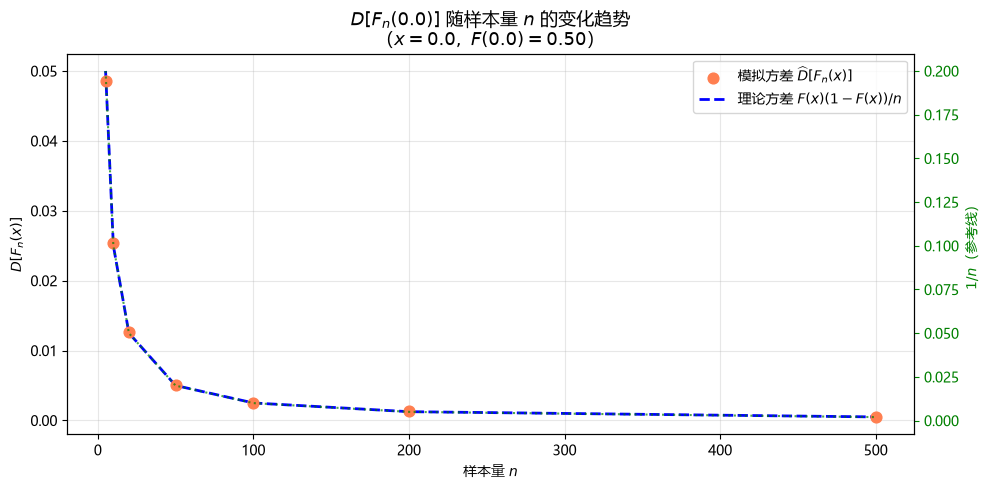

✅ 方差以 O(1/n) 的速度趋于 0，因此 F_n(x) 是 F(x) 的相合估计。
  n=  5:  模拟方差=0.048544  理论方差=0.050000  比值(模拟/理论)=0.971
  n= 10:  模拟方差=0.025439  理论方差=0.025000  比值(模拟/理论)=1.018
  n= 20:  模拟方差=0.012644  理论方差=0.012500  比值(模拟/理论)=1.012
  n= 50:  模拟方差=0.005033  理论方差=0.005000  比值(模拟/理论)=1.007
  n=100:  模拟方差=0.002523  理论方差=0.002500  比值(模拟/理论)=1.009
  n=200:  模拟方差=0.001323  理论方差=0.001250  比值(模拟/理论)=1.059
  n=500:  模拟方差=0.000475  理论方差=0.000500  比值(模拟/理论)=0.950


In [42]:
# === 代码演示:验证 EDF 的方差随 n 增大而趋于 0 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# 研究不同样本量下 EDF 的方差
sample_sizes = [5, 10, 20, 50, 100, 200, 500]
N_sim = 2000        # 每个样本量模拟次数
x_fixed = 0.0       # 固定点 x=0(F(0)=0.5)

empirical_variances = []
theoretical_variances = []

for n in sample_sizes:
    # Monte Carlo 模拟
    Fn_vals = np.zeros(N_sim)
    for i in range(N_sim):
        sample = np.random.normal(0, 1, n)
        Fn_vals[i] = np.mean(sample <= x_fixed)

    # 经验方差
    emp_var = np.var(Fn_vals, ddof=1)
    empirical_variances.append(emp_var)

    # 理论方差: F(x)(1-F(x))/n
    F_x = norm.cdf(x_fixed, 0, 1)
    theo_var = F_x * (1 - F_x) / n
    theoretical_variances.append(theo_var)

# 绘图
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(sample_sizes, empirical_variances, color='coral', s=60,
           label='模拟方差 $\\widehat{D}[F_n(x)]$', zorder=5)
ax.plot(sample_sizes, theoretical_variances, 'b--', linewidth=2,
        label='理论方差 $F(x)(1-F(x))/n$')

ax.set_xlabel('样本量 $n$')
ax.set_ylabel('$D[F_n(x)]$')
ax.set_title(f'$D[F_n({x_fixed})]$ 随样本量 $n$ 的变化趋势\n'
              f'($x={x_fixed},\\ F({x_fixed})={norm.cdf(x_fixed):.2f}$)', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# 在次坐标轴标注 1/n 趋势
ax_twin = ax.twinx()
ax_twin.plot(sample_sizes, 1/np.array(sample_sizes), 'g:', linewidth=1.5, alpha=0.7)
ax_twin.set_ylabel('$1/n$(参考线)', color='green')
ax_twin.tick_params(colors='green')

plt.tight_layout()
plt.show()

print(f'✅ 方差以 O(1/n) 的速度趋于 0,因此 F_n(x) 是 F(x) 的相合估计.')
for n, ev, tv in zip(sample_sizes, empirical_variances, theoretical_variances):
    print(f'  n={n:3d}:  模拟方差={ev:.6f}  理论方差={tv:.6f}  比值(模拟/理论)={ev/tv:.3f}')

### 1.5.4 数值示例

对三年级 10 个孩子的阅读能力分数:

$$
95, \ 86, \ 78, \ 90, \ 62, \ 73, \ 89, \ 92, \ 84, \ 76
$$

经验分布函数为:

$$
F_n(x)=
\begin{cases}
0,      & x<62, \\[2pt]
\dfrac{1}{10},   & 62\le x<73, \\[6pt]
\dfrac{2}{10},   & 73\le x<76, \\[6pt]
\dfrac{3}{10},   & 76\le x<78, \\[6pt]
\dfrac{4}{10},   & 78\le x<84, \\[6pt]
\dfrac{5}{10},   & 84\le x<86, \\[6pt]
\dfrac{6}{10},   & 86\le x<89, \\[6pt]
\dfrac{7}{10},   & 89\le x<90, \\[6pt]
\dfrac{8}{10},   & 90\le x<92, \\[6pt]
\dfrac{9}{10},   & 92\le x<95, \\[6pt]
1,      & x\ge95.
\end{cases}
$$

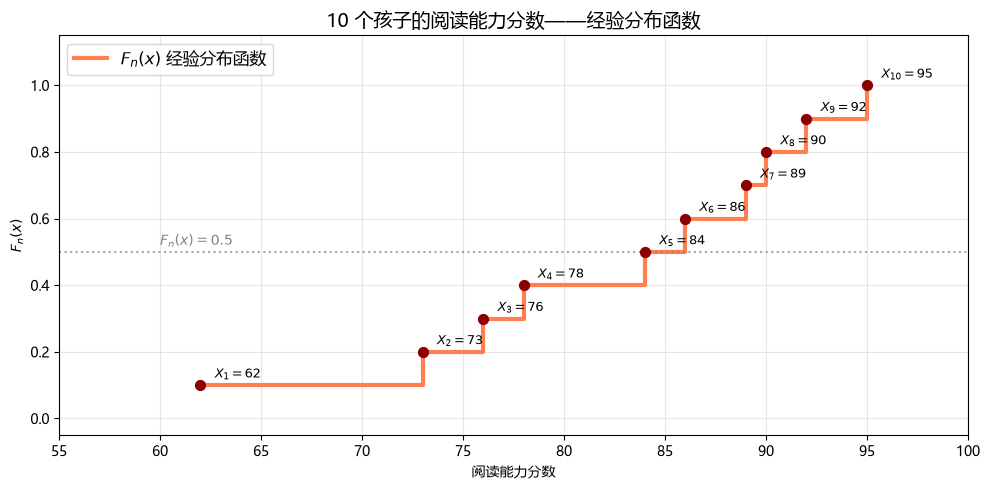

经验分布函数 Fn(x) 的数值表
x 的范围                Fn(x)     
------------------------------
  [ 62,  73)    0.1/10
  [ 73,  76)    0.2/10
  [ 76,  78)    0.3/10
  [ 78,  84)    0.4/10
  [ 84,  86)    0.5/10
  [ 86,  89)    0.6/10
  [ 89,  90)    0.7/10
  [ 90,  92)    0.8/10
  [ 92,  95)    0.9/10
  [ 95,   ∞)    1.0/10
  [95, ∞)          10/10


In [43]:
# === 代码演示:阅读能力分数的经验分布函数 ===
import numpy as np
import matplotlib.pyplot as plt

# 三年级 10 个孩子的阅读能力分数
scores = np.array([95, 86, 78, 90, 62, 73, 89, 92, 84, 76])
n = len(scores)

# 排序
sorted_scores = np.sort(scores)

# 计算 EDF 的跳跃点
y_edf = np.arange(1, n + 1) / n

# 绘图
fig, ax = plt.subplots(figsize=(10, 5))

# 绘制 EDF 阶梯函数
ax.step(sorted_scores, y_edf, where='post', color='coral',
        linewidth=3, label='$F_n(x)$ 经验分布函数')

# 标注每个跳跃点
for i, (score, prob) in enumerate(zip(sorted_scores, y_edf)):
    ax.scatter(score, prob, color='darkred', s=50, zorder=5)
    ax.annotate(f'  $X_{{{i+1}}}={score}$', (score, prob),
                textcoords='offset points', xytext=(5, 5), fontsize=9)

# 标记具体数值
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7)
ax.text(60, 0.52, '$F_n(x)=0.5$', fontsize=10, color='gray')

ax.set_xlabel('阅读能力分数')
ax.set_ylabel('$F_n(x)$')
ax.set_title('10 个孩子的阅读能力分数 -- 经验分布函数', fontsize=14)
ax.set_xlim(55, 100)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 表格展示
print('=' * 40)
print('经验分布函数 Fn(x) 的数值表')
print('=' * 40)
print(f'{"x 的范围":<20} {"Fn(x)":<10}')
print('-' * 30)
for i in range(n):
    left = sorted_scores[i]
    right = sorted_scores[i+1] if i < n-1 else '∞'
    print(f'  [{left:3d}, {str(right):>3})    {y_edf[i]:>3}/{n}')
print(f'  [95, ∞)          {n}/{n}')